# Task 1: Problem Identification

## Problem Type: Image Classification

The given dataset represents an Image Classification problem.

The dataset contains manufacturing product surface images belonging to four different categories:

- normal
- scratch
- dent
- stain

Each image belongs to only one class, and the goal is to classify the image into its correct defect category using a Convolutional Neural Network (CNN).

This problem is suitable for image classification because the model predicts a single label for each input image rather than detecting object locations or segmenting image regions.

Task 2 — Dataset Exploration

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
dataset_path = "images"

In [3]:
print(os.listdir(dataset_path))

['.ipynb_checkpoints', 'dent', 'normal', 'scratch', 'stain']


In [4]:
classes = ['dent', 'normal', 'scratch', 'stain']

In [5]:
for class_name in classes:
    
    class_path = os.path.join(dataset_path, class_name)
    
    print(class_name, ":", len(os.listdir(class_path)))

dent : 2
normal : 2
scratch : 2
stain : 2


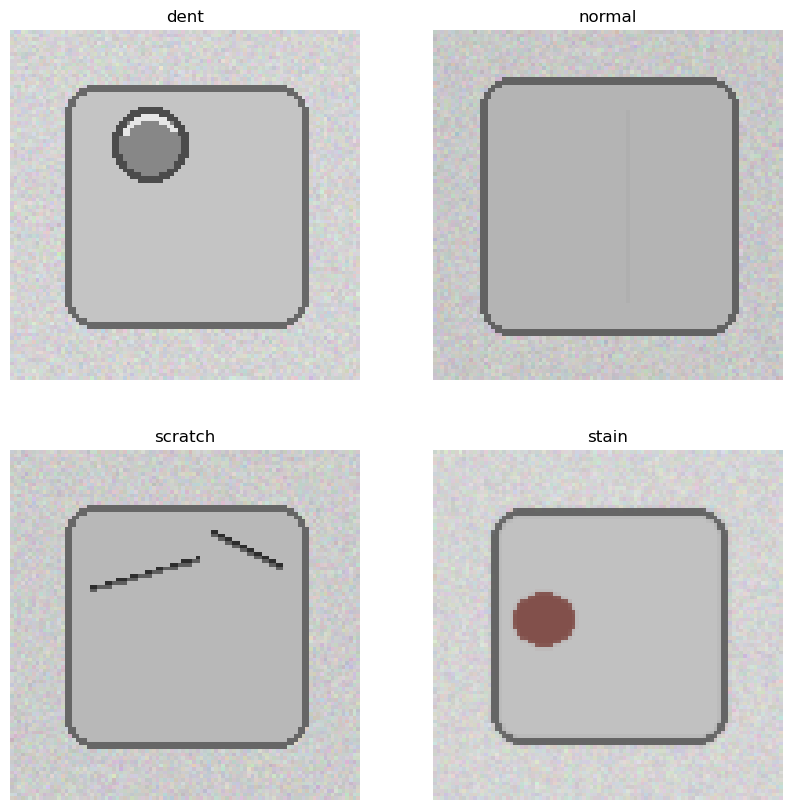

In [11]:
plt.figure(figsize=(10,10))

for i, class_name in enumerate(classes):
    
    class_path = os.path.join(dataset_path, class_name)
    
    image_name = os.listdir(class_path)[0]
    
    image_path = os.path.join(class_path, image_name)
    
    img = plt.imread(image_path)
    
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [12]:
for class_name in classes:
    
    class_path = os.path.join(dataset_path, class_name)
    
    image_name = os.listdir(class_path)[0]
    
    image_path = os.path.join(class_path, image_name)
    
    img = Image.open(image_path)
    
    print(class_name, ":", img.size)

dent : (96, 96)
normal : (96, 96)
scratch : (96, 96)
stain : (96, 96)


##  Task 2:Dataset Imbalance Observation

The dataset appears reasonably balanced because each class contains a similar number of images. Balanced datasets help CNN models learn all classes effectively without bias toward a specific category.

# Task 3: Image Preprocessing

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [14]:
datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    validation_split=0.2,
    
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

| Parameter        | Purpose                        |
| ---------------- | ------------------------------ |
| rescale          | normalizes pixel values        |
| validation_split | creates train/validation split |
| rotation_range   | image augmentation             |
| zoom_range       | zoom augmentation              |
| horizontal_flip  | flips images                   |


In [15]:
train_data = datagen.flow_from_directory(
    
    "images",
    
    target_size=(128,128),
    
    batch_size=32,
    
    class_mode='categorical',
    
    subset='training'
)

Found 384 images belonging to 4 classes.


In [16]:
validation_data = datagen.flow_from_directory(
    
    "images",
    
    target_size=(128,128),
    
    batch_size=32,
    
    class_mode='categorical',
    
    subset='validation'
)

Found 96 images belonging to 4 classes.


| Parameter   | Meaning                    |
| ----------- | -------------------------- |
| target_size | resizes images             |
| batch_size  | images processed together  |
| class_mode  | multi-class classification |
| subset      | training or validation     |


In [17]:
print(train_data.class_indices)

{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


# Task 4: CNN Model Creation

In [18]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [19]:
model = Sequential()

In [20]:
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

In [21]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [22]:
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

In [23]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [24]:
model.add(Flatten())

In [25]:
model.add(
    Dense(
        128,
        activation='relu'
    )
)

In [26]:
model.add(
    Dense(
        4,
        activation='softmax'
    )
)

In [27]:
model.compile(
    
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

# Task 5: Model Training and Evaluation

In [28]:
history = model.fit(
    
    train_data,
    
    validation_data=validation_data,
    
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2604 - loss: 2.3610 - val_accuracy: 0.2500 - val_loss: 1.3929
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2370 - loss: 1.3843 - val_accuracy: 0.4375 - val_loss: 1.3541
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 968ms/step - accuracy: 0.4479 - loss: 1.3369 - val_accuracy: 0.2604 - val_loss: 1.3401
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 940ms/step - accuracy: 0.4974 - loss: 1.2443 - val_accuracy: 0.5208 - val_loss: 1.1478
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 916ms/step - accuracy: 0.6302 - loss: 1.0131 - val_accuracy: 0.5938 - val_loss: 0.9356
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 931ms/step - accuracy: 0.6875 - loss: 0.8323 - val_accuracy: 0.7083 - val_loss: 0.7349
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 911ms/step - accuracy: 0.7604 - loss: 0.6178 - val_accuracy: 0.7604 - val_loss: 0.5496
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 959ms/step - accuracy: 0.7839 - loss: 0.5035 - val_accuracy: 

In [31]:
import matplotlib.pyplot as plt

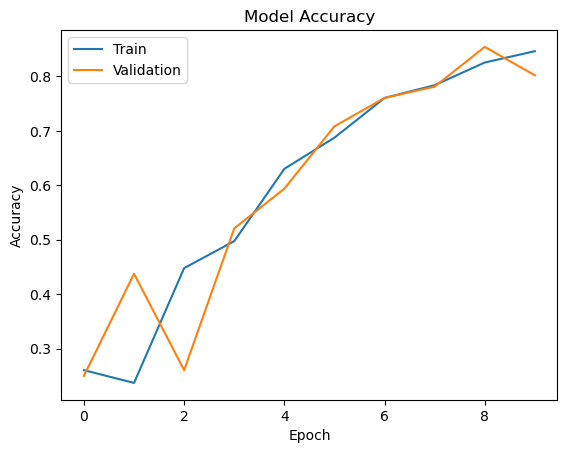

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [33]:
plt.savefig("results/accuracy_loss_curves.png")

<Figure size 640x480 with 0 Axes>

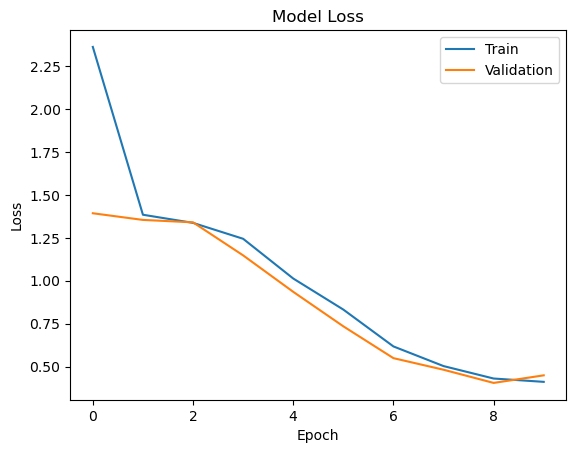

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [35]:
predictions = model.predict(validation_data)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step


In [36]:
predicted_classes = predictions.argmax(axis=1)

In [37]:
true_classes = validation_data.classes

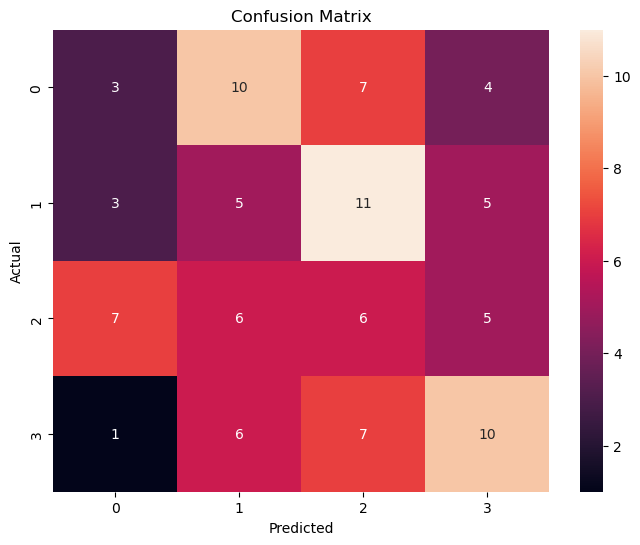

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [39]:
plt.savefig("results/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes
))

              precision    recall  f1-score   support

           0       0.21      0.12      0.16        24
           1       0.19      0.21      0.20        24
           2       0.19      0.25      0.22        24
           3       0.42      0.42      0.42        24

    accuracy                           0.25        96
   macro avg       0.25      0.25      0.25        96
weighted avg       0.25      0.25      0.25        96



In [42]:
import numpy as np

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


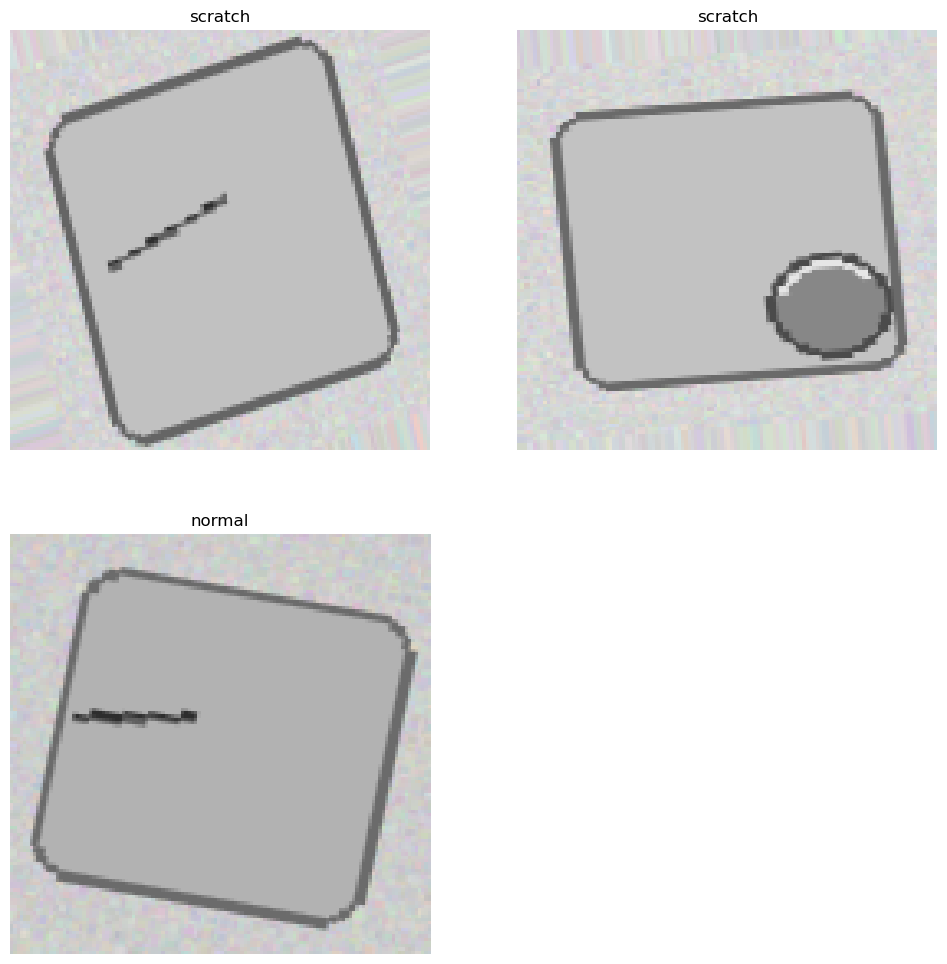

In [45]:
class_labels = list(validation_data.class_indices.keys())

plt.figure(figsize=(12,12))

for i in range(3):
    
    image, label = validation_data[i]
    
    prediction = model.predict(image)
    
    predicted_class = np.argmax(prediction[0])
    
    predicted_label = class_labels[predicted_class]
    
    plt.subplot(2,2,i+1)
    
    plt.imshow(image[0])
    
    plt.title(predicted_label)
    
    plt.axis("off")

plt.show()

In [46]:
plt.savefig("sample_predictions/prediction_outputs.png")

<Figure size 640x480 with 0 Axes>

# Task 6: CNN Concept Explanation

## What is Convolution?

Convolution is a mathematical operation used in CNNs to detect important features from images such as edges, textures, and patterns. Small filters move across the image and extract useful visual information.

## Why is Pooling Used?

Pooling reduces the size of feature maps while keeping important information. It helps reduce computation and prevents overfitting.

## Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) introduces non-linearity into the neural network. It helps the CNN learn complex image patterns efficiently and speeds up training.

## Why are CNNs Better than Regular Feed-Forward Networks for Images?

CNNs are designed specifically for image data. They automatically detect spatial patterns and important visual features, while regular feed-forward networks cannot efficiently process image structures.

# Task 7: Business Use Case Mapping

## Manufacturing Industry Use Case

This computer vision solution can be used in manufacturing industries for automated defect detection. CNN models can identify defects such as scratches, dents, and stains on product surfaces during quality inspection.

Using AI-based defect detection improves product quality, reduces manual inspection effort, minimizes human error, and increases manufacturing efficiency.